### Stochastic interpolant demo: unit Gaussian → Scaled Beta Distribution

A minimal, self-contained illustration of the `eesi` interpolant framework in 1D.

We learn a generative map from a simple **base** distribution to a more complex
**target**:

- **Base** `p_0`: a single Gaussian, `N(0, I)` (unit variance, zero covariance).
- **Target** `p_1`: a shifted scaled Beta distribution, `8*(Beta(3/2,3/2)-1/2)`.

The `EESI` model trains a drift field `b(t, x)` and (optionally) score field `s(t, x)` along
the stochastic interpolant

$$x_t = \alpha(t)\,x_0 + \beta(t)\,x_1 + \gamma(t)\,z,\qquad z\sim N(0, I),$$

then estimates the entropy difference using a variety of strategies:
- integrate the learned probability-flow ODE (or reverse-time SDE) from
`t=0` (base) to `t=1` (target), acculumating entropy as `b * s` along the paths. 
- directly sample the interpolant, taking the average of `b * s`
- directly sample the interpolant, taking the average of `div(b)` independent of the score

This notebook covers **setup & instantiation**,
the **training loop**, **sampling**, and **contour plotting**.

In [2]:
# --- imports & environment ---
import sys
import pathlib

import torch
import numpy as np
import matplotlib.pyplot as plt
import scipy.special
from torch.distributions import MultivariateNormal

# Make the `eesi` package importable whether the notebook is launched from the
# repo root or from this experiments/ folder (no install required).
_cwd = pathlib.Path.cwd()
for _root in (_cwd, _cwd.parent):
    if (_root / "eesi" / "__init__.py").exists():
        sys.path.insert(0, str(_root))
        break
from eesi import EESI, TimeMLP, GaussianMixture, ConstrainedMLP

%matplotlib inline
torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### 1. Base and target distributions

The base is standard normal, `N(0, I)`. The target is a two-component Gaussian
mixture built from `eesi.datasets.GaussianMixture`, whose weights, means and
full (correlated) covariances are drawn once from a fixed `seed` and then held
constant.

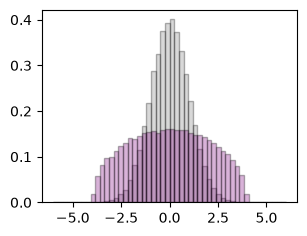

In [3]:
# --- base: single 1D Gaussian, unit variance, zero covariance ---
base = MultivariateNormal(torch.zeros(1, device=device), torch.eye(1, device=device))

# --- target: shifted and scaled Beta distribution (looks like a Wigner semicircle)
target = torch.distributions.Beta(torch.tensor([1.5], device=device), 
                            torch.tensor([1.5], device=device))

# Sanity check: draw and scatter samples from each distribution.
scale = 4
x0_vis = base.sample((100000,)).cpu()
x1_vis = 2*scale*(target.sample((100000,)).cpu()-0.5)

# Symmetric plot limits that comfortably contain both distributions.
LIM = float(torch.cat([x0_vis, x1_vis]).abs().max().ceil()) + 1.0

edges = np.linspace(-LIM,LIM,51)
fig, ax = plt.subplots(1, 1, figsize=(3.3, 2.5))
ax.hist(x0_vis,bins=edges,alpha=0.3,color='grey',edgecolor="k",density=True)
ax.hist(x1_vis,bins=edges,alpha=0.3,color='purple',edgecolor="k",density=True)
plt.show()

### 2. Model & sampler setup

`EESI` wraps two `TimeMLP` fields — the drift `net_b` and the score `net_s`.

- `path="trig"` uses the ramped interpolant `x_t = cos^2(πt/2) x_0 + sin^2(πt/2) x_1`.
- `gamma="sin2"` adds the smooth latent-noise schedule `γ(t) = sin^2(πt)`, so the
  score is trained with the cheap antithetic denoising objective (no divergence
  estimate).

In [4]:
net_b = TimeMLP(d=1, hidden=64, n_layers=6, activation="silu")
net_s = TimeMLP(d=1, hidden=64, n_layers=6, activation="silu")

model = EESI(
    net_b, net_s,
    d=1,
    path="trig2",
    gamma="sqrt",
    gamma_scale=1.0,
    #learn_score=False
).to(device)

opt = torch.optim.Adam(model.parameters(), lr=1e-3)
#print(model)

### 3. Training loop
For demonstrating the effect of limited data, we sample `x1` just once
as we assume this is difficult to sample.
Each iteration then draws a fresh batch from the base `x_0`, forms the interpolant
internally, and returns the drift/score losses. We minimise their sum.

In [5]:
torch.manual_seed(1)
batch = 20000 
x1 = 8*(target.sample((batch,))-0.5)

n_iters = 10000
hist_b, hist_s = [], []
for it in range(n_iters):
    x0 = base.sample((batch,))
    losses = model.loss(x1, x0)          # {"b": drift loss, "s": score loss}
    loss = losses["b"] + losses["s"]

    opt.zero_grad()
    loss.backward()
    opt.step()

    hist_b.append(losses["b"].item())
    hist_s.append(losses["s"].item())
    if it % 500 == 0:
        print(f"iter {it:4d}  loss_b={hist_b[-1]:+.3f}  loss_s={hist_s[-1]:+.3f}")
print(f"iter {it:4d}  loss_b={hist_b[-1]:+.3f}  loss_s={hist_s[-1]:+.3f}")


iter    0  loss_b=+0.003  loss_s=-0.000
iter  500  loss_b=-0.932  loss_s=-0.362
iter 1000  loss_b=-0.971  loss_s=-0.376
iter 1500  loss_b=-0.921  loss_s=-0.377
iter 2000  loss_b=-0.952  loss_s=-0.375
iter 2500  loss_b=-0.948  loss_s=-0.382
iter 3000  loss_b=-0.946  loss_s=-0.391
iter 3500  loss_b=-0.962  loss_s=-0.378
iter 4000  loss_b=-0.958  loss_s=-0.379
iter 4500  loss_b=-0.972  loss_s=-0.380
iter 5000  loss_b=-0.976  loss_s=-0.382
iter 5500  loss_b=-0.981  loss_s=-0.389
iter 6000  loss_b=-0.914  loss_s=-0.384
iter 6500  loss_b=-0.972  loss_s=-0.374
iter 7000  loss_b=-0.971  loss_s=-0.379
iter 7500  loss_b=-0.923  loss_s=-0.394
iter 8000  loss_b=-0.944  loss_s=-0.369
iter 8500  loss_b=-1.000  loss_s=-0.382
iter 9000  loss_b=-0.964  loss_s=-0.387
iter 9500  loss_b=-0.927  loss_s=-0.382
iter 9999  loss_b=-0.927  loss_s=-0.381


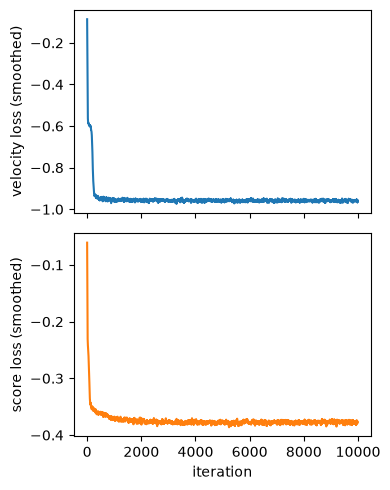

In [6]:
# Training curves (smoothed).
def smooth(v, k=20):
    v = np.asarray(v)
    if len(v) < k:
        return v
    return np.convolve(v, np.ones(k) / k, mode="valid")

fig, ax = plt.subplots(2,1,sharex=True,figsize=(4,5))
ax[0].plot(smooth(hist_b),'-C0')
ax[0].set_ylabel("velocity loss (smoothed)")
ax[1].plot(smooth(hist_s),'-C1')
ax[1].set_xlabel("iteration") 
ax[1].set_ylabel("score loss (smoothed)")
plt.tight_layout()
plt.show()

### 4. Sampling

Map base samples to the target with the model's built-in samplers:

- `model.sample_ode` integrates the probability-flow **ODE** `dx/dt = b(t, x)`
  with Heun's method (drift only).
- `model.sample_sde` integrates the reverse-time **SDE** with Euler–Maruyama,
  using both the drift `b` and the learned score `s` (diffusion `eps`).

In [18]:
# Draw base samples and push them through the model's built-in samplers.
torch.manual_seed(1)
batch = 200000
x1 = target.sample((batch,))
x0 = base.sample((batch,))

gen_ode = torch.clamp((model.sample_ode(x0, n_steps=100)+scale)/(2*scale),1e-4,1-1e-4)          # probability-flow ODE (drift only)
gen_sde = torch.clamp((model.sample_sde(x0, n_steps=100, eps=0.3)+scale)/(2*scale),1e-4,1-1e-4)     # reverse-time SDE (drift + score)

# How well do generated samples match the target? (mean log-dens
# ity)

ref = target.log_prob(x1).mean() - np.log(2.0*scale)
base_ref = base.log_prob(x0).mean()
print(f"mean target log-prob — ODE sampler : {target.log_prob(gen_ode).mean()- np.log(2.0*scale):+.3f}")
print(f"mean target log-prob — SDE sampler : {target.log_prob(gen_sde).mean()- np.log(2.0*scale):+.3f}")
print(f"mean target log-prob — true target : {ref:+.3f}")
print(f"mean base log-prob — true target : {base_ref:+.3f}")
print(f"estimated entropy change : {-ref + base_ref:+.3f}")

mean target log-prob — ODE sampler : -2.034
mean target log-prob — SDE sampler : -2.037
mean target log-prob — true target : -2.030
mean base log-prob — true target : -1.419
estimated entropy change : +0.612


### 5. Entropy along the paths

The trajectory-returning `*_entropy_traj` samplers augment every path with the
running integral

$$\Delta\text{S}(t) = -\int_0^t b(x_{t'}, t')\cdot s(x_{t'}, t')\,dt',$$

an estimate of how the (differential) entropy of the flowing density changes as
samples move from base to target. With `sample_ode_entropy_traj` we get the full
`ΔS(t)` curve for every sample at once, so we can plot many paths together
and read off the ensemble-mean entropy change.

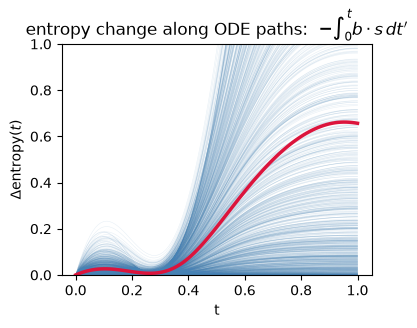

mean ΔS(1)  (base → target): +0.61279


In [46]:
# Trace the running entropy change along many ODE paths.
torch.manual_seed(1)
batch = 20000
x1 = 8*(target.sample((batch,))-0.5)

torch.manual_seed(6)
means =  []
for k in range(20):
    x0 = base.sample((batch,))
    traj, ent_traj, ts = model.sample_sde_entropy_traj(x0, eps=0, n_steps=100)
    means.append(ent_traj[-1,:].mean().cpu().numpy())

ts_c = ts.cpu().numpy()[:1000]
ent_c = ent_traj.cpu().numpy()[:,:1000]         # [n_steps+1, B]

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(ts_c, ent_c, c="steelblue", lw=0.4, alpha=0.12)                  # individual paths
ax.plot(ts_c, ent_c.mean(axis=1), c="crimson", lw=2.5, label="ensemble mean")
ax.axhline(0.0, c="k", lw=0.6, ls="--")
ax.set_xlabel("t"); ax.set_ylabel(r"$\Delta$entropy$(t)$")
ax.set_title(r"entropy change along ODE paths:  $-\int_0^t b\cdot s\,dt'$")
#ax.legend()
ax.set_ylim(-0.5,4)
ax.set_ylim(0,1)
plt.show()

print(f"mean ΔS(1)  (base → target): {np.mean(means):+.5f}")

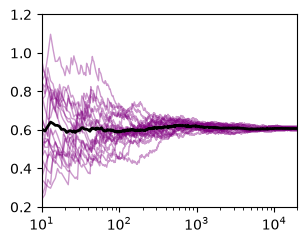

0.6074609
0.005466615


In [66]:
# Examine convergence based on number of trajectories simulated
vals = []
torch.manual_seed(11241)
batch = 20000

plt.figure(figsize=(3.3,2.5))

mom = []
for k in range(20):
    x0 = base.sample((batch,))
    x,ent = model.sample_sde_entropy(x0, eps=1, n_steps=100)
    ent_cpu = ent.cpu().numpy()
    vals.append(np.mean(ent_cpu))
    #print(np.mean(ent_cpu))
    mean = np.cumsum(ent_cpu)/np.arange(1,batch+1)
    mom.append(mean)
    plt.plot(np.arange(1,batch+1),mean,'-',color='purple',alpha=0.4,lw=1)
mom = np.mean(mom,axis=0)
plt.plot(np.arange(1,batch+1),mom,'-',color='k',lw=2)
#plt.yscale('log')
plt.xscale('log')
plt.xlim(10,20000)
plt.ylim(0.2,1.2)
plt.show()
print(np.mean(vals))
print(np.std(vals))


### 6. Generation-Free Entropy Estimate

In [50]:
torch.manual_seed(1)
batch = 20000
x1 = 8*(target.sample((batch,))-0.5)

means = []
for n in range(100):
    x0 = base.sample((batch,))
    ent = model.entropy_estimate_dot(x1,x0) # b*s formulation
    means.append(ent.mean().cpu().numpy())
print(np.mean(means))
print(np.std(means))

0.6237039
0.009001171


Somewhat less accurate than I'd like. Not sure why exactly. Perhaps there is some reparameterization or conditioning that can be done to improve this.

In [51]:

torch.manual_seed(1)
batch = 20000
x1 = 8*(target.sample((batch,))-0.5)

means = []
for n in range(100):
    x0 = base.sample((batch,))
    ent = model.entropy_estimate_div(x1,x0)
    means.append(ent.mean().detach().cpu().numpy())
print(np.mean(means))
print(np.std(means))

0.6120022
0.0054302043
